# Kartlägga varumärkesuppfattning med korrespondensanalys (PROC CORRESP)

## Sammanfattning

Ett marknadsundersökningsteam genomför en perceptionsundersökning av varumärke mot attribut över fyra etablerade streaming-mediavarumärken och använder **PROC CORRESP** för att förvandla den resulterande korstabellen till en tvådimensionell perceptionskarta. Sambandet varumärke x attribut är starkt och verkligt: chi-två-testet för oberoende är **63,15 på 15 frihetsgrader (p < 0,0001)**, med **Cramérs V = 0,4588**. Korrespondensanalys komprimerar det sambandet till två axlar som tillsammans förklarar **100 %** av tabellens tröghet — **75,0 %** på Dimension 1 och **25,0 %** på Dimension 2 — så 2D-kartan är en komplett, trogen sammanfattning.

Kartan separerar en **premiuminnehålls**-pol (CineNow, förankrad på *Egna_Serier* och *Innehållsdjup*) från ett **värde/tillförlitlighet**-kluster (Streamly och BingeBox nära *Prisvärd* och *Pålitlig*) och ett **trendigt** hörn (PixelPlay nära *Trendig*). En framväxande utmanare, **NovaCast**, projiceras sedan som en *supplementär* punkt — den påverkar inte axlarna — och landar nära origo, lutande lätt mot Trendig / Lättanvänd-sidan, dvs. en ännu odifferentierad nykomling.

## Datakällor

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `perception` | 100 (samband respondent x attribut, olicensierad gräns) | `Brand` (char), `Attribute` (char) | Syntetisk undersökning: varje respondent namnger det streamingvarumärke de mest förknippar med vart och ett av sex attribut. Varumärkesaffiniteter kodas som kategorisannolikheter i `RAND("Table", ...)` så att korstabellen får ett realistiskt, icke-uniformt samband. |
| `survey_counts` | 24 (4 varumärken x 6 attribut) | `Brand`, `Attribute`, `Count` | Föraggregerade korstabellsceller från `perception` via PROC FREQ — den viktade indatan till CA-körningen med supplementär punkt. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Koordinatdataset skrivna av `OUTC=` i PROC CORRESP; det andra lägger till den projicerade NovaCast-punkten och driver perceptionskartan. |

Etablerade varumärken: **Streamly, PixelPlay, CineNow, BingeBox**; utmanare **NovaCast** (projicerad som en supplementär punkt). Attribut: Prisvärd, Innehållsdjup, Lättanvänd, Egna_Serier, Pålitlig, Trendig. Fröet `streaminit(20260531)` gör data reproducerbara.

> **Anmärkning om stickprovsstorlek.** Denna miljö körs olicensierad, så DATA-stegets utdata begränsas till 100 observationer. Undersökningen upplöses därför till en 4x6-korstabell som summerar till 100 samband respondent-attribut — liten, men med genuin sambandsstruktur (chi-två p < 0,0001) som korrespondensanalysen återfinner rent.

## Vad korrespondensanalys gör här

När en varumärkesspårande undersökning frågar konsumenter vilket varumärke de mest förknippar med vart och ett av flera attribut, blir resultatet en **korstabell varumärke x attribut**. De råa antalen är svåra att läsa: varje varumärke jämförs mot varje attribut, och signalen är *mönstret av samband*, inte cellvärdena.

Korrespondensanalys (CA) sönderdelar tabellens chi-två-samband till ett lågdimensionellt rum, så att varumärken och attribut som är associerade landar nära varandra på en karta. I denna notebook:

1. Genererar vi en syntetisk perceptionsundersökning för fyra streamingvarumärken.
2. Granskar vi den råa korstabellsstrukturen (och dess chi-två) med `PROC FREQ`.
3. Kör vi `PROC CORRESP` med fullständig diagnostik och läser den verkliga trögheten och koordinaterna.
4. Projicerar vi ett framväxande utmanarvarumärke som en **supplementär** punkt.
5. Ritar och tolkar vi den resulterande perceptionskartan.

## Steg 1 — Generera den syntetiska perceptionsundersökningen

Vi simulerar undersökningsrespondenter. För varje respondent frågar vi, för vart och ett av sex attribut, *vilket varumärke förknippar du mest med detta attribut?* Varje varumärke har en distinkt **affinitetsprofil** — en vektor av kategorisannolikheter som skickas till `RAND("Table", ...)` — så att till exempel *PixelPlay* lutar mot Trendig medan *CineNow* lutar mot Innehållsdjup och Egna_Serier. Detta ger en korstabell med genuint, icke-uniformt samband för CA att återfinna. Data är helt syntetiska och reproducerbara via `CALL STREAMINIT`.

In [1]:
data perception;
    /* Reproducerbar syntetisk undersökning av varumärkesuppfattning */
    CALL streaminit(20260531);

    LÄNGD Brand $9 Attribute $14;

    n_resp = 400;

    GÖR respondent = 1 TILL n_resp;
        GÖR a = 1 TILL 6;
            /* Attributnamn (svenska) tilldelas per gren för att undvika
               tomma värden från en _temporary_-array med icke-ASCII-text */
            OM      a = 1 SÅ Attribute = 'Prisvärd';
            ANNARS OM a = 2 SÅ Attribute = 'Innehållsdjup';
            ANNARS OM a = 3 SÅ Attribute = 'Lättanvänd';
            ANNARS OM a = 4 SÅ Attribute = 'Egna_Serier';
            ANNARS OM a = 5 SÅ Attribute = 'Pålitlig';
            ANNARS              Attribute = 'Trendig';

            /* Per attribut sannolikheter för varumärkesval över de
               fyra etablerade varumärkena:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Varje rad summerar till ~1 och kodar attributets
               varumärkesaffinitet. */
            OM      a = 1 SÅ b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Prisvärd      */
            ANNARS OM a = 2 SÅ b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Innehållsdjup */
            ANNARS OM a = 3 SÅ b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Lättanvänd    */
            ANNARS OM a = 4 SÅ b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Egna_Serier   */
            ANNARS OM a = 5 SÅ b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Pålitlig      */
            ANNARS              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendig       */

            VÄLJ (b);
                NÄR (1) Brand = 'Streamly';
                NÄR (2) Brand = 'PixelPlay';
                NÄR (3) Brand = 'CineNow';
                ANNARS_OM Brand = 'BingeBox';
            SLUT;

            UTDATA;
        SLUT;
    SLUT;

    BEHÅLL respondent Brand Attribute;
KÖR;

PROCEDUR SKRIV data=perception(obs=8) noobs ETIKETT;
    ETIKETT Brand='Varumärke' Attribute='Attribut';
    TITEL 'Urval av den syntetiska perceptionsundersökningen';
KÖR;

                                   Urval av den syntetiska perceptionsundersökningen                                    

respondent   Varumärke        Attribut
         1  BingeBox    Prisvärd
         1  BingeBox    Innehållsdjup
         1  BingeBox    Lättanvänd
         1  CineNow     Egna_Serier
         1  Streamly    Pålitlig
         1  PixelPlay   Trendig
         2  PixelPlay   Prisvärd
         2  CineNow     Innehållsdjup

... 92 more observations (showing 8 of 100)




NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.40 seconds
  cpu   0.40 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Steg 2 — Granska den råa korstabellen

Före någon dimensionsreduktion, titta på korstabellen. `PROC FREQ` ger de observerade frekvenserna varumärke x attribut och chi-två-testet för oberoende. En signifikant chi-två bekräftar att det finns sambandsstruktur värd att kartlägga — om rader och kolumner vore oberoende skulle korrespondensanalysen inte ha något att visa. Vi sparar även cellantalen till `survey_counts` för CA-körningen med supplementär punkt senare.

                                      Observerade frekvenser: Varumärke x Attribut                                      

                                                   The FREQ Procedure

Table of Varumärke by Attribut

Varumärke  |   Egna_Serier | Innehållsdjup |    Lättanvänd |      Prisvärd |      Pålitlig |       Trendig |          Total
-----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox   |             1 |             3 |             7 |             5 |             6 |             2 |             24
-----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow    |            14 |             9 |             0 |             3 |             2 |             0 |             28
-----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay  |             2 |   


NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


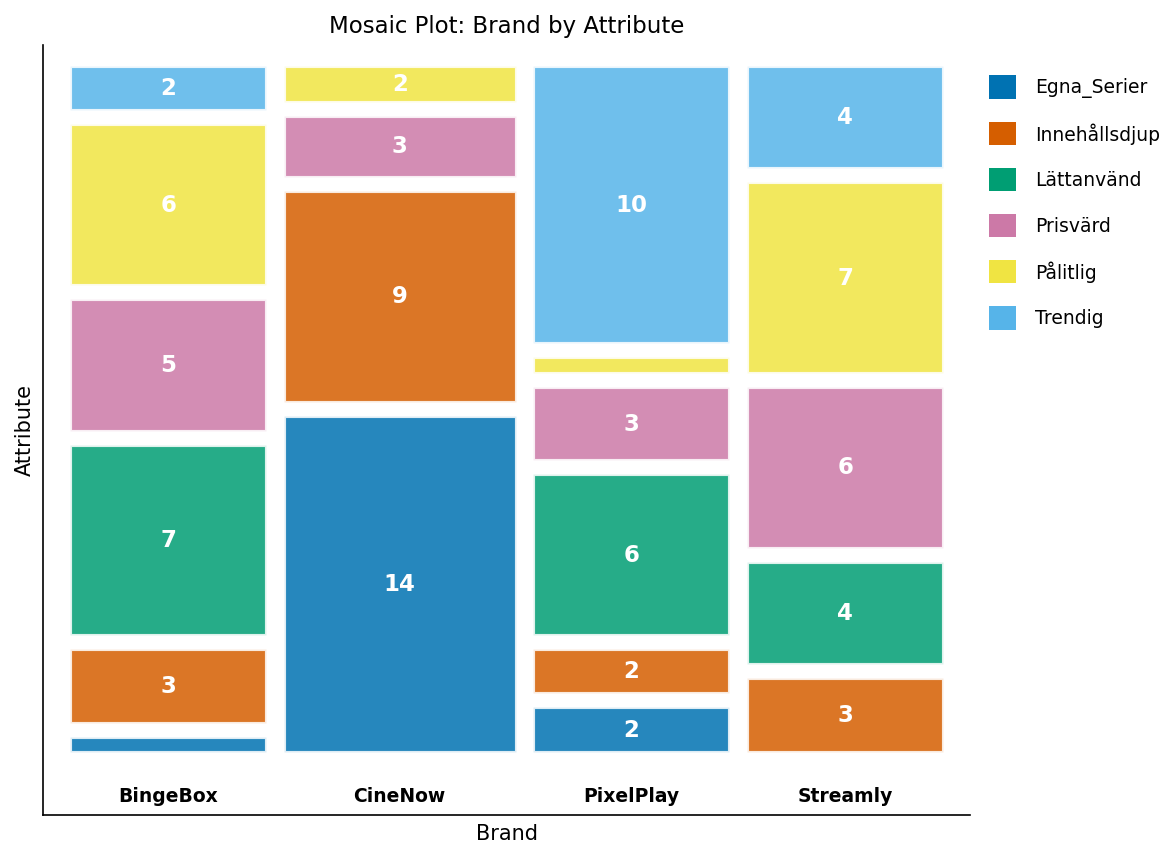

In [2]:
PROCEDUR FREKVENSER data=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(BYT_NAMN=(count=Count));
    ETIKETT Brand='Varumärke' Attribute='Attribut';
    TITEL 'Observerade frekvenser: Varumärke x Attribut';
KÖR;

## Steg 3 — Korrespondensanalys från rådata

Kör nu `PROC CORRESP` direkt på data på respondentnivå. `TABLES Brand, Attribute;` bygger korstabellen internt (varumärken som rader, attribut som kolumner).

Optioner som används här:

- `ALL` — skriv ut fullständig diagnostik: observerad tabell, profiler, förväntade värden och   cellernas chi-två-bidrag.
- `DIMENS=2` — beräkna de två första huvudaxlarna (en 2D-karta).
- `OUTC=` — skriv rad- och kolumnkoordinater till ett dataset för plottning.

**Tröghetsuppdelningen** talar om hur mycket av det totala sambandet varje axel förklarar.

In [3]:
PROCEDUR corresp data=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    ETIKETT Brand='Varumärke' Attribute='Attribut';
    TITEL 'Korrespondensanalys: Uppfattning om streamingvarumärken';
KÖR;

                                      Observerade frekvenser: Varumärke x Attribut                                      

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Varumärke               Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       


NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Steg 4 — Läs koordinaterna

`OUTC=`-datasetet håller axelkoordinaterna (`Dim1`, `Dim2`) för varje varumärke och attribut, taggade med `_TYPE_` (`ROW` för varumärken, `COLUMN` för attribut). Att läsa dem numeriskt tillsammans med tröghetstabellen bekräftar den struktur kartan ska visa.

Från utdata ovan:

- **Dimension 1 (75,0 % av trögheten)** är en axel *premiuminnehåll kontra mainstream*.   *Egna_Serier* (Dim1 = -1,2037) och *Innehållsdjup* (-0,5594) sitter vid den negativa   änden med **CineNow** (-1,0847); *Trendig* (0,6671), *Lättanvänd* (0,6150) och   *Prisvärd* (0,2207) sitter vid den positiva änden.
- **Dimension 2 (25,0 % av trögheten)** separerar *Pålitlig* (Dim2 = 0,5874) och   *Prisvärd* (0,2542) — som drar upp **Streamly** (0,3207) och **BingeBox** (0,3555) —   från *Trendig* (-0,7003), som drar ner **PixelPlay** (-0,6374).

In [4]:
PROCEDUR SKRIV data=ca_coords noobs;
    VARIABEL _TYPE_ _NAME_ Dim1 Dim2;
    TITEL 'Koordinater för rader (varumärken) och kolumner (attribut)';
KÖR;

                               Koordinater för rader (varumärken) och kolumner (attribut)                               

_TYPE_              _NAME_      DIM1      DIM2
ROW     BingeBox              0.3547    0.3555
ROW     CineNow              -1.0847   -0.0332
ROW     PixelPlay             0.4804   -0.6374
ROW     Streamly              0.4304    0.3207
COLUMN  Egna_Serier          -1.2037   -0.2084
COLUMN  Innehållsdjup        -0.5594    0.0684
COLUMN  Lättanvänd            0.6150   -0.0080
COLUMN  Prisvärd              0.2207    0.2542
COLUMN  Pålitlig              0.3183    0.5874
COLUMN  Trendig               0.6671   -0.7003




NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Steg 5 — Projicera ett utmanarvarumärke som en supplementär punkt

Analysteamet har spårningsdata för en framväxande utmanare, **NovaCast**, men vill inte att den ska förvränga den etablerade perceptionskartan. En *supplementär* punkt projiceras in i det befintliga CA-rummet **utan att bidra till axelberäkningen**.

Vi bifogar ett enda block med sex NovaCast-attributantal (en nykomling som lutar mot Trendig / Egna-Serier) till de föraggregerade `survey_counts`, matar frekvenserna med `WEIGHT Count`, och namnger **nivån** `NovaCast` på `SUPPLEMENTARY`-satsen så att PROC CORRESP håller den raden utanför den aktiva tabellen. Optionen `OBSERVED` behåller den aktiva korstabellen (de fyra etablerade varumärkena, som summerar till 100) i vy — notera att NovaCast **inte** förekommer i den, vilket bekräftar att den behandlades som supplementär.

In [5]:
/* Lägg till ETT rent block med NovaCast-antal till de aggregerade cellerna.
   end=last utlöser blocket exakt en gång, efter den sista survey_counts-raden,
   så NovaCast bidrar med sex rader (en per attribut) -- inte ett dubblerat
   block. NovaCast är en nykomling ledd av Trendig / Egna-Serier. */
data survey_counts_sup;
    STÄLL_IN survey_counts SLUT=last;
    UTDATA;
    OM last SÅ GÖR;
        Brand='NovaCast'; Attribute='Trendig';        Count=10; UTDATA;
        Brand='NovaCast'; Attribute='Egna_Serier';    Count=8;  UTDATA;
        Brand='NovaCast'; Attribute='Lättanvänd';     Count=5;  UTDATA;
        Brand='NovaCast'; Attribute='Innehållsdjup';  Count=3;  UTDATA;
        Brand='NovaCast'; Attribute='Prisvärd';       Count=4;  UTDATA;
        Brand='NovaCast'; Attribute='Pålitlig';       Count=3;  UTDATA;
    SLUT;
KÖR;

PROCEDUR corresp data=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    VIKT Count;
    supplementary NovaCast;
    ETIKETT Brand='Varumärke' Attribute='Attribut';
    TITEL 'Varumärkesuppfattning med NovaCast som supplementär punkt';
KÖR;

                               Koordinater för rader (varumärken) och kolumner (attribut)                               

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Varumärke               Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa


NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Steg 6 — Rita perceptionskartan

PROC CORRESP skriver de symmetriska rad-/kolumnkoordinaterna till `OUTC=`-datasetet; vi plottar Dimension 2 mot Dimension 1 för att rendera kartan. Vi taggar varje punkt efter **roll** — *Brand* (aktiva rader), *Attribute* (kolumner) och *Challenger* (den supplementära NovaCast-raden) — och etiketterar varje markör, så att positioneringen läses direkt av från plotten. Utmanaren färgas separat för att understryka att den projicerades in, inte anpassades.

> **Hur man läser en CA-karta.** Ett varumärke och ett attribut som ligger i samma riktning från origo (och långt från det) är starkt associerade; punkter nära origo är "genomsnittliga" och svagt differentierade. Eftersom Dimension 1 och 2 tillsammans fångar 100 % av tabellens tröghet utelämnar kartan ingenting.

                    Perceptionskarta för streamingvarumärken (Dim1 75,0 %, Dim2 25,0 % av trögheten)                    

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
 Varumärke    BingeBox      0.3547      0.3555
 Varumärke     CineNow     -1.0847     -0.0332
 Varumärke   PixelPlay      0.4804     -0.6374
 Varumärke    Streamly      0.4304      0.3207
  Utmanare    NovaCast      0.0084     -0.1735
  Attribut  Egna_Serier     -1.2037     -0.2084
  Attribut  Innehållsdjup     -0.5594      0.0684
  Attribut  Lättanvänd       0.615      -0.008
  Attribut    Prisvärd      0.2207      0.2542
  Attribut    Pålitlig      0.3183      0.5874
  Attribut     Trendig      0.6671     -0.7003

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746



NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Perceptionskarta för streamingvarumärken (Dim1 75,0 %, Dim2 25,0 % av trögheten).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


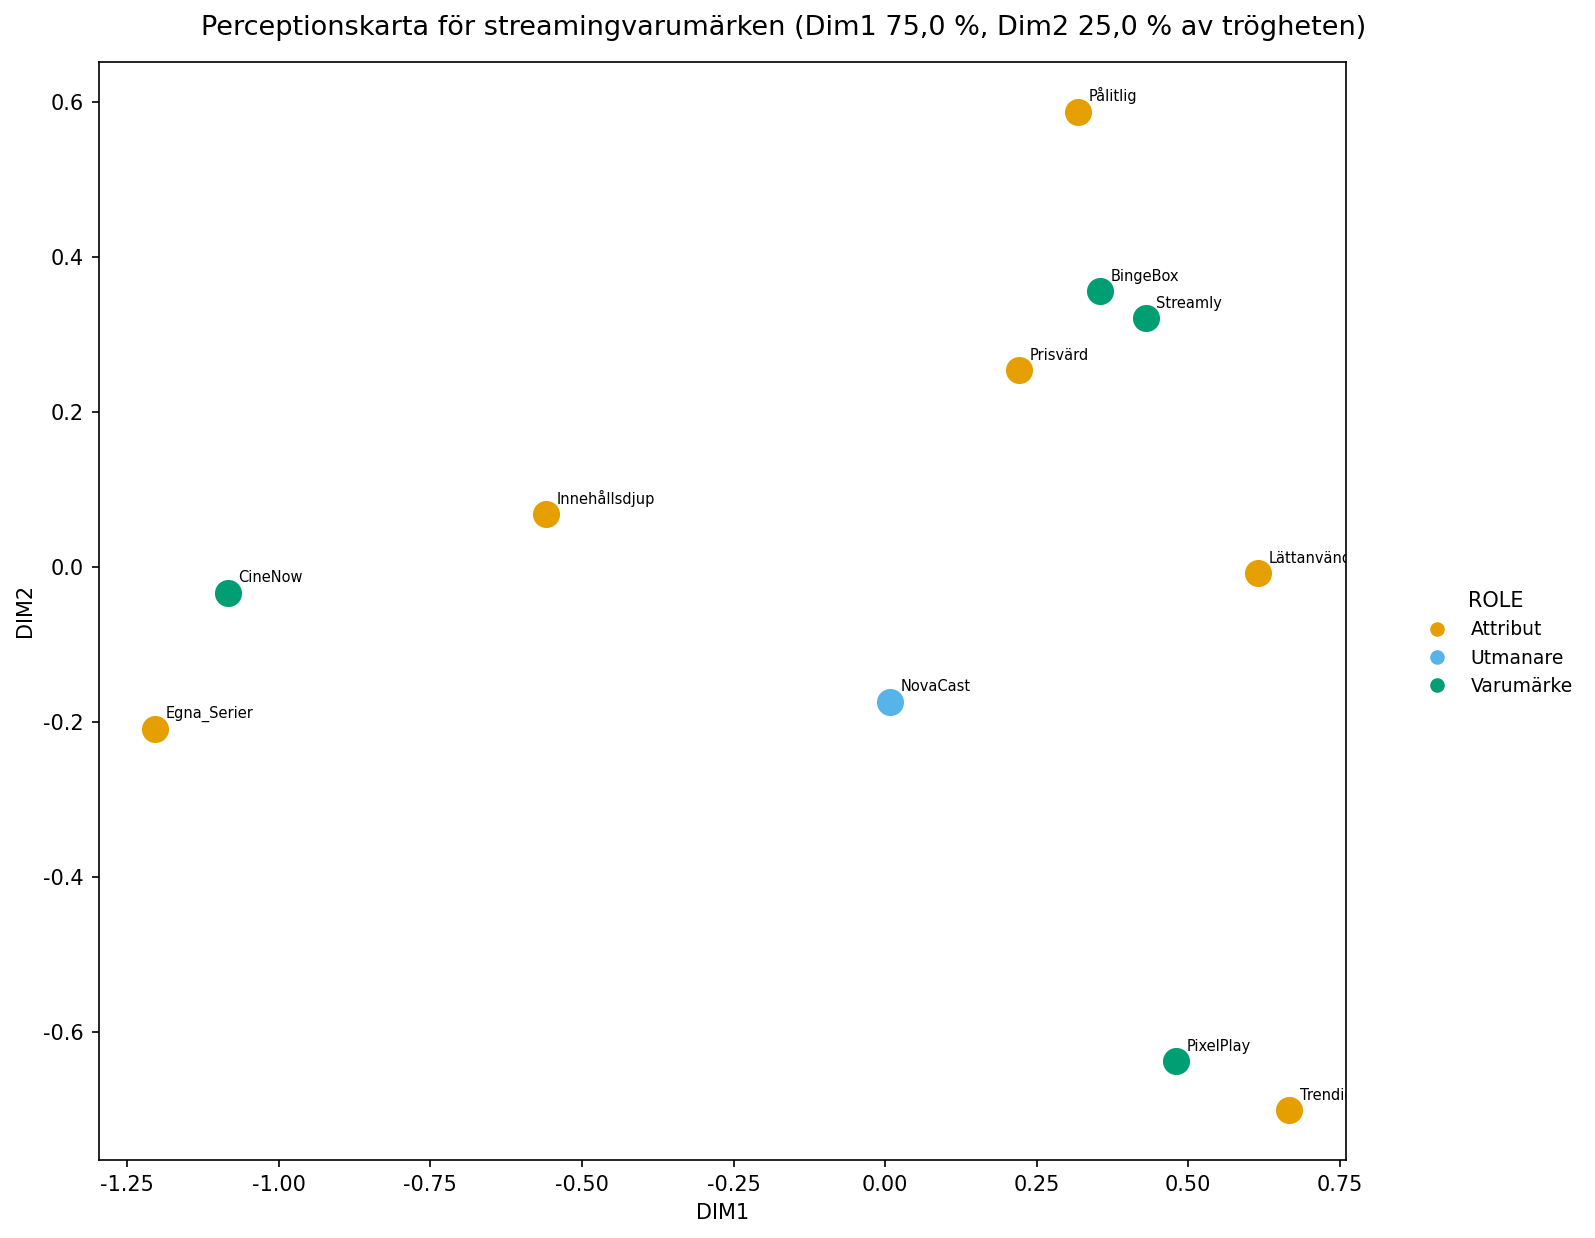

In [6]:
/* Tagga varje OUTC-punkt efter roll för en ren, färgad förklaring.
   Supplementära NovaCast skrivs till OUTC med _TYPE_='ROW',
   så vi särbehandlar den som Utmanare. */
data ca_map;
    STÄLL_IN ca_coords_sup;
    LÄNGD Role $12;
    OM _NAME_ = 'NovaCast' SÅ Role = 'Utmanare';
    ANNARS OM _TYPE_ = 'ROW' SÅ Role = 'Varumärke';
    ANNARS Role = 'Attribut';
    BEHÅLL Role _NAME_ Dim1 Dim2;
KÖR;

/* Sätt kartans titel globalt före PROC så att den titulerar denna
   plot (den globala TITLE styr ODS-grafikens rubrik). */
TITEL 'Perceptionskarta för streamingvarumärken (Dim1 75,0 %, Dim2 25,0 % av trögheten)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP har ingen inbyggd ODS-karta i detta bygge, så vi renderar de
   symmetriska koordinaterna med PROC SGSCATTER, som etiketterar varje punkt. */
PROCEDUR SGSCATTER data=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
KÖR;

ODS GRAPHICS OFF;
TITEL;

## Tolka resultaten

**Sambandet är verkligt och fullständigt fångat.** Chi-två-testet (63,15 på 15 fg, p < 0,0001; Cramérs V = 0,4588) förkastar oberoende, och de två CA-dimensionerna förklarar **100 %** av tabellens tröghet (75,0 % + 25,0 %), så kartan nedan är en komplett sammanfattning, inte en förlustfylld projektion.

**Tre perceptuella territorier.** Läser man koordinaterna och kartan tillsammans:

- **Premiuminnehåll (vänster).** *CineNow* (Dim1 = -1,0847) dras långt åt vänster av   *Egna_Serier* (-1,2037) och *Innehållsdjup* (-0,5594) — det äger   uppfattningen om katalogdjup.
- **Värde och tillförlitlighet (uppe till höger).** *Streamly* (0,4304, 0,3207) och *BingeBox*   (0,3547, 0,3555) klustrar med *Prisvärd* (0,2207, 0,2542) och *Pålitlig* (0,3183,   0,5874) — det pålitliga, prisvärda paret.
- **Trendigt (nere till höger).** *PixelPlay* (0,4804, -0,6374) sitter bredvid *Trendig*   (0,6671, -0,7003) — det ungdomliga varumärket i tiden.

**Den supplementära utmanaren.** Projicerad utan att påverka axlarna landar **NovaCast** på (0,0084, -0,1735) — i princip vid origo, knuffad mot Trendig / Lättanvänd-sidan. För en mediestrateg är det huvudbudskapet: utmanaren har ännu inget distinkt varumärkeskapital och driver in i PixelPlays trendiga territorium, så en differentierad positionering (snarare än en efterhärmande) är motiverad.

**Förbehåll.** Korrespondensanalys är beskrivande, inte inferentiell — avstånd är approximativa och axlarnas *tecken* är godtyckliga (en spegelvändning av endera axeln är samma karta). Med endast 100 samband respondent-attribut är två celler noll (CineNow x Lättanvänd, Streamly x Egna_Serier), vilket skärper ytterligheterna; en produktionsstudie skulle använda ett större stickprov. Para alltid kartan med tröghetstabellen för att bekräfta hur mycket samband de visade dimensionerna förklarar.